In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/pranaysingh25/mnist-data/mnist_test.csv
/kaggle/input/datasets/pranaysingh25/mnist-data/mnist_train.csv


**NOTE:** This notebook was originally created on Kaggle for using GPU optimizations from Kaggle (GPU T4 x2) for faster image processing. If you want to work with it locally, change the Kaggle file paths of the train and test datasets to the downloaded data folder's mnist files train and test paths instead: (../data/mnist_train.csv) and (../data/mnist_test.csv).
---

The GPU’s ability to use massive parallel processing is precisely why it dominates when handling images or 2D grids like spectrograms (image where the X-axis is Time and the Y-axis is Frequency).
A CPU is built like a high-performance sports car. It has a few extremely fast, powerful cores (typically 4 to 16). It is designed for serial processing—meaning it takes a task, finishes it incredibly quickly, and moves to the next one.
A GPU is built like a fleet of thousands of delivery trucks. Its individual cores are much simpler and slower than a CPU core, but it has thousands of them working simultaneously (parallel processing).

Images are inherently independent at the pixel level. If you want to multiply every pixel in an image by a filter weight, the calculation for the top-left pixel doesn't care about what the bottom-right pixel is doing.

Because of this independence, the GPU can say:

Core 1: Calculate Pixel 1

Core 2: Calculate Pixel 2

Core 3: Calculate Pixel 3

...

Core 2000: Calculate Pixel 2000

Instead of waiting in line, thousands of pixel calculations happen at the exact same millisecond.

**In PyTorch, we don't just shove a massive NumPy array into the model. Instead, we use a Dataset and a DataLoader. This is a massive advantage for competitions like the BirdCLEF+ 2026 competition because you'll eventually be dealing with gigabytes of audio files that can't all fit in your RAM at once.The DataLoader acts like a conveyor belt, grabbing small "batches" of data from your disk, preprocessing them, and handing them to the GPU just-in-time.**

In [2]:
''' In PyTorch, we wrap our CSV data in a class that inherits from
torch.utils.data.Dataset.
This is where we handle the reshape and normalization logic.
'''

import torch
from torch.utils.data import Dataset, DataLoader

class MNISTDataset(Dataset):
    def __init__(self, csv_file):
        self.data = pd.read_csv(csv_file)
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        # Extract label and pixels
        label = self.data.iloc[idx, 0]
        # Reshape to (Channels, Height, Width) -> PyTorch uses (C, H, W)
        pixels = self.data.iloc[idx, 1:].values.reshape(1, 28, 28).astype('float32') / 255.0
        
        return torch.tensor(pixels), torch.tensor(label)

In [3]:
# Paths from your Kaggle Input sidebar
train_path = '/kaggle/input/datasets/pranaysingh25/mnist-data/mnist_train.csv'
test_path = '/kaggle/input/datasets/pranaysingh25/mnist-data/mnist_train.csv'

# Create Dataset objects
train_dataset = MNISTDataset(train_path)
test_dataset = MNISTDataset(test_path)

# Create DataLoader objects
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Quick check
images, labels = next(iter(train_loader))
print(f"Batch Image Shape: {images.shape}") # Expect [64, 1, 28, 28]
print(f"Batch Label Shape: {labels.shape}") # Expect [64]

Batch Image Shape: torch.Size([64, 1, 28, 28])
Batch Label Shape: torch.Size([64])


In [4]:
import torch.nn as nn
import torch.nn.functional as F

class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        # 1 input channel, 32 output, 3x3 kernel
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.2)
        
        # 64 channels * 5 * 5 spatial size after pooling
        self.fc1 = nn.Linear(64 * 5 * 5, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 5 * 5) # Flattening for the Dense layer
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [5]:
import torch.optim as optim
import torch.nn as nn

# 1. Instantiate the model (Make sure your MNIST_CNN class cell was run!)
# If you haven't run the class cell, 'MNIST_CNN' will also give a NameError.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MNIST_CNN().to(device) 

# 2. Define Criterion and Optimizer
criterion = nn.CrossEntropyLoss() # CrossEntropyLoss handles Softmax and Log-Loss automatically
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam is the gold standard for CNNs

print(f"Model initialized on: {device}")

Model initialized on: cuda


In [6]:
import torch.optim as optim

# 1. Setup Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. Training Loop
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        # Move to GPU/CPU
        images, labels = images.to(device), labels.to(device)
        
        # Zero the gradients (crucial step!)
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass (Backpropagation)
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        running_loss += loss.item()
        
    # 3. Validation Phase
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f} | Accuracy: {100 * correct / total:.2f}%")

Epoch 1 | Loss: 0.2678 | Accuracy: 98.00%
Epoch 2 | Loss: 0.0858 | Accuracy: 98.54%
Epoch 3 | Loss: 0.0620 | Accuracy: 99.02%
Epoch 4 | Loss: 0.0507 | Accuracy: 99.26%
Epoch 5 | Loss: 0.0419 | Accuracy: 99.41%


**Why PyTorch felt different (The "Manual" Magic)**

---

**In your training logs, you can see the Loss steadily dropping from 0.2401 to 0.0402. Because you wrote the loop yourself, you were effectively controlling the "backpropagation" math you learned during your scratch project.**


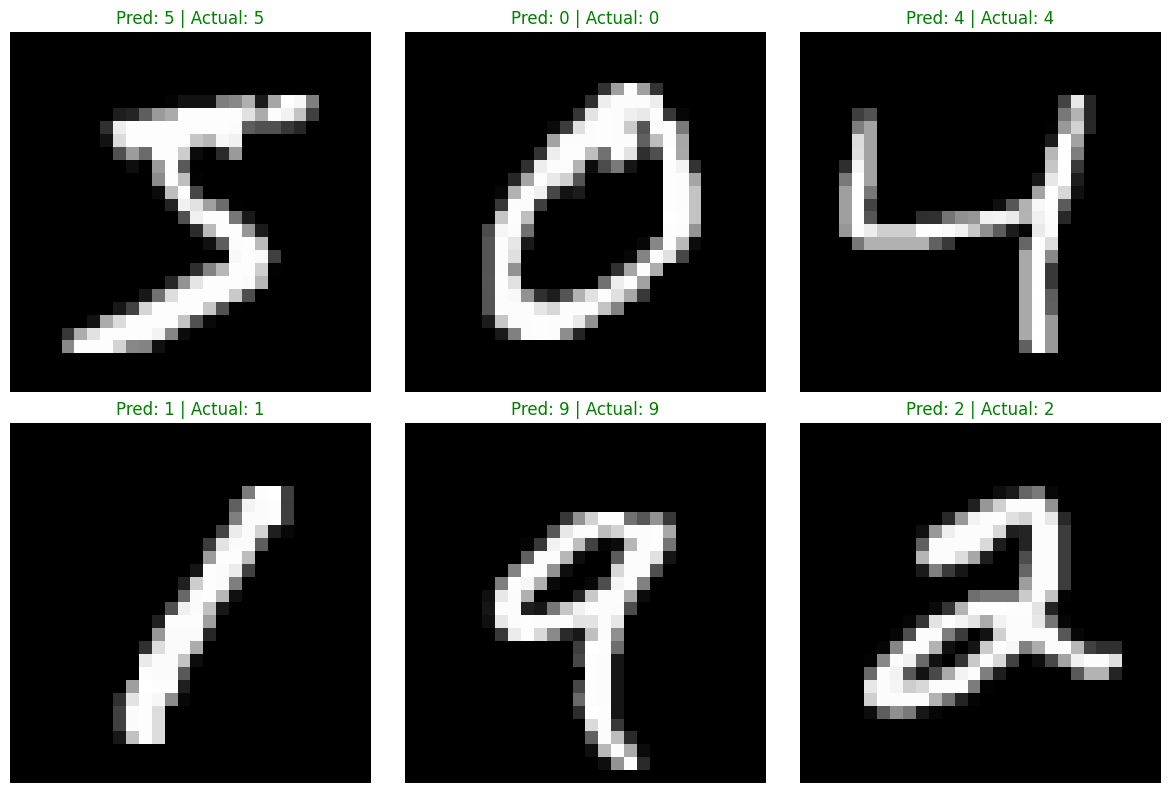

In [7]:
import matplotlib.pyplot as plt

# 1. Grab a single batch from the test loader
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

# 2. Get predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

# 3. Plotting logic
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i+1)
    # Reshape back to 28x28 for display
    plt.imshow(images[i].cpu().numpy().squeeze(), cmap='gray')
    
    color = 'green' if preds[i] == labels[i] else 'red'
    plt.title(f"Pred: {preds[i]} | Actual: {labels[i]}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()